# Sentinel-5P HCHO — SentinelHub / CDSE

**Nguồn:** Sentinel-5P TROPOMI via SentinelHub CDSE  
**Band:** `HCHO` — Formaldehyde column density (mol/m²)  
**Mục đích:** HCHO = proxy VOC + biomass burning → nguồn thứ cấp PM2.5  
**Cấu trúc:** Giống `sentinelhub_satellite_crawling.ipynb` (S5P pipeline)  

**Features tạo ra:**  
`hcho_valid_pixels`, `hcho_mean`, `hcho_std`, `hcho_min`, `hcho_max`, `hcho_median`

**Output:** `data/processed/hcho_s5p_daily.csv` → merge vào `daily_merged.csv`

## A. Import + Config

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

from sentinelhub import (
    CRS,
    BBox,
    DataCollection,
    MimeType,
    MosaickingOrder,
    SentinelHubRequest,
    SHConfig,
    bbox_to_dimensions,
)

ROOT     = Path("D:/Bussiness_plan/Multimodal_PM25")
PROC_DIR = ROOT / "data/processed"
RAW_DIR  = ROOT / "data/raw/hcho_s5p"; RAW_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV  = PROC_DIR / "hcho_s5p_daily.csv"
MERGED   = PROC_DIR / "daily_merged.csv"

# ── CDSE credentials (same as satellite pipeline) ────────────────────────────
config = SHConfig()
config.sh_client_id     = "sh-aba2f8e9-da97-47f3-8cae-a5a1fbeede2d"
config.sh_client_secret = "DPBslOq7z6pumggnCpQAQBDKfIE3fhQ9"
config.sh_token_url     = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
config.sh_base_url      = "https://sh.dataspace.copernicus.eu"

# Sentinel-5P CDSE collection
s5p_cdse = DataCollection.SENTINEL5P.define_from(
    "S5P_CDSE", service_url=config.sh_base_url
)

# 6 stations Hà Nội
STATIONS = {
    2161292: (21.0152, 105.7999),
    2161306: (21.0500, 105.7400),
    4946811: (21.0491, 105.8831),
    4946812: (21.0031, 105.7947),
    4946813: (21.0052, 105.8418),
    6123215: (20.9933, 105.9441),
}

print("Config ready. Stations:", len(STATIONS))

d:\Bussiness_plan\Multimodal_PM25\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Config ready. Stations: 6


## B. Helper functions (same as satellite pipeline)

In [2]:
def make_bbox(lat, lon, delta, crs=CRS.WGS84):
    return BBox([lon - delta, lat - delta, lon + delta, lat + delta], crs=crs)


def safe_stats(arr, prefix):
    arr = np.array(arr, dtype=np.float32)
    arr = arr[~np.isnan(arr)]
    if arr.size == 0:
        return {
            f"{prefix}_mean":   np.nan,
            f"{prefix}_std":    np.nan,
            f"{prefix}_min":    np.nan,
            f"{prefix}_max":    np.nan,
            f"{prefix}_median": np.nan,
        }
    return {
        f"{prefix}_mean":   float(np.nanmean(arr)),
        f"{prefix}_std":    float(np.nanstd(arr)),
        f"{prefix}_min":    float(np.nanmin(arr)),
        f"{prefix}_max":    float(np.nanmax(arr)),
        f"{prefix}_median": float(np.nanmedian(arr)),
    }

## C. HCHO extractor (same pattern as NO2/CO/SO2)

In [3]:
def get_hcho_features(lat, lon, date_str, delta=0.3, resolution=5000):
    """
    Fetch Sentinel-5P HCHO for one station, one day.
    delta=0.3 deg (~33km box), resolution=5000m — same as other S5P bands.
    """
    bbox = make_bbox(lat, lon, delta)
    size = bbox_to_dimensions(bbox, resolution=resolution)

    evalscript = """
    //VERSION=3
    function setup() {
        return {
            input: [{ bands: ["HCHO", "dataMask"] }],
            output: { bands: 2, sampleType: "FLOAT32" }
        };
    }
    function evaluatePixel(sample) {
        return [sample.HCHO, sample.dataMask];
    }
    """

    request = SentinelHubRequest(
        evalscript=evalscript,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=s5p_cdse,
                time_interval=(date_str, date_str),
                mosaicking_order=MosaickingOrder.MOST_RECENT,
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox,
        size=size,
        config=config,
    )

    try:
        img  = request.get_data()[0]
        band = np.where(img[..., 1] == 1, img[..., 0].astype(float), np.nan)
        features = {"hcho_valid_pixels": int(np.sum(~np.isnan(band)))}
        features.update(safe_stats(band, "hcho"))
    except Exception as e:
        print(f"  HCHO error {date_str}: {e}")
        features = {"hcho_valid_pixels": np.nan}
        features.update(safe_stats([], "hcho"))

    return features


# ── Quick test ────────────────────────────────────────────────────────────────
test = get_hcho_features(21.0152, 105.7999, "2024-03-01")
print("Test result:", test)

Test result: {'hcho_valid_pixels': 0, 'hcho_mean': nan, 'hcho_std': nan, 'hcho_min': nan, 'hcho_max': nan, 'hcho_median': nan}


## D. Build dataset — tất cả trạm × tất cả ngày trong daily_merged.csv

In [4]:
# Lấy danh sách ngày từ daily_merged.csv
main = pd.read_csv(MERGED, parse_dates=["date"])
dates_all = sorted(main["date"].dt.strftime("%Y-%m-%d").unique())
print(f"Total dates: {len(dates_all)}  ({dates_all[0]} → {dates_all[-1]})")
print(f"Total requests: {len(STATIONS)} × {len(dates_all)} = {len(STATIONS)*len(dates_all):,}")

Total dates: 807  (2024-02-06 → 2026-05-15)
Total requests: 6 × 807 = 4,842


In [5]:
all_station_dfs = []

for loc_id, (lat, lon) in STATIONS.items():
    cache_file = RAW_DIR / f"hcho_s5p_{loc_id}.csv"

    if cache_file.exists():
        df_st = pd.read_csv(cache_file)
        done  = set(df_st["date"].tolist())
        remaining = [d for d in dates_all if d not in done]
        print(f"Station {loc_id}: {len(done)} cached, {len(remaining)} remaining")
    else:
        df_st     = pd.DataFrame()
        remaining = dates_all
        print(f"Station {loc_id}: starting fresh ({len(remaining)} dates)")

    rows = []
    for i, date_str in enumerate(remaining):
        feat = get_hcho_features(lat, lon, date_str)
        feat["location_id"] = loc_id
        feat["date"]        = date_str
        rows.append(feat)

        # Save checkpoint every 50 dates
        if (i + 1) % 50 == 0 or (i + 1) == len(remaining):
            df_new = pd.DataFrame(rows)
            df_st  = pd.concat([df_st, df_new], ignore_index=True)
            df_st.to_csv(cache_file, index=False)
            rows   = []
            print(f"  [{loc_id}] checkpoint {i+1}/{len(remaining)}")

    all_station_dfs.append(df_st)
    print(f"  Station {loc_id} done: {len(df_st)} rows")

hcho_df = (pd.concat(all_station_dfs, ignore_index=True)
           .sort_values(["location_id", "date"])
           .reset_index(drop=True))

print(f"\nTotal rows : {len(hcho_df)}")
print(f"Coverage   : {hcho_df['hcho_mean'].notna().mean()*100:.1f}%")
print(hcho_df[["hcho_mean","hcho_max","hcho_median"]].describe().round(6))

Station 2161292: starting fresh (807 dates)
  [2161292] checkpoint 50/807
  [2161292] checkpoint 100/807
  [2161292] checkpoint 150/807
  [2161292] checkpoint 200/807
  [2161292] checkpoint 250/807
  [2161292] checkpoint 300/807
  [2161292] checkpoint 350/807
  [2161292] checkpoint 400/807
  [2161292] checkpoint 450/807
  [2161292] checkpoint 500/807
  [2161292] checkpoint 550/807
  [2161292] checkpoint 600/807
  [2161292] checkpoint 650/807
  [2161292] checkpoint 700/807
  [2161292] checkpoint 750/807
  [2161292] checkpoint 800/807
  [2161292] checkpoint 807/807
  Station 2161292 done: 807 rows
Station 2161306: starting fresh (807 dates)
  [2161306] checkpoint 50/807
  [2161306] checkpoint 100/807
  [2161306] checkpoint 150/807
  [2161306] checkpoint 200/807
  [2161306] checkpoint 250/807
  [2161306] checkpoint 300/807
  [2161306] checkpoint 350/807
  [2161306] checkpoint 400/807
  [2161306] checkpoint 450/807
  [2161306] checkpoint 500/807
  [2161306] checkpoint 550/807
  [2161306] c

## E. Visualize

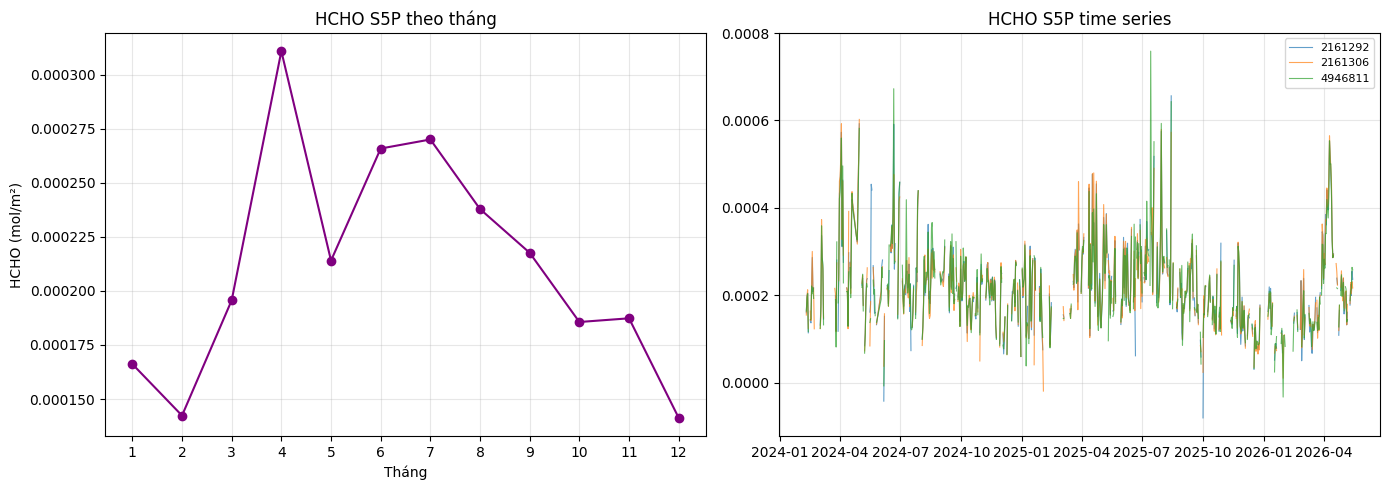

In [6]:
import matplotlib.pyplot as plt

hcho_df["month"] = pd.to_datetime(hcho_df["date"]).dt.month
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly = hcho_df.groupby("month")["hcho_mean"].mean()
monthly.plot(ax=axes[0], marker="o", color="purple")
axes[0].set_title("HCHO S5P theo tháng", fontsize=12)
axes[0].set_xlabel("Tháng"); axes[0].set_ylabel("HCHO (mol/m²)")
axes[0].set_xticks(range(1, 13)); axes[0].grid(alpha=0.3)

for loc_id in list(STATIONS.keys())[:3]:
    sub = hcho_df[hcho_df["location_id"] == loc_id]
    axes[1].plot(pd.to_datetime(sub["date"]), sub["hcho_mean"],
                 alpha=0.7, linewidth=0.8, label=str(loc_id))
axes[1].set_title("HCHO S5P time series", fontsize=12)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / "outputs/hcho_s5p_seasonal.png", dpi=120, bbox_inches="tight")
plt.show()

## F. Correlation HCHO vs PM2.5

Pearson r (HCHO S5P vs PM2.5): -0.017  (n=1598)


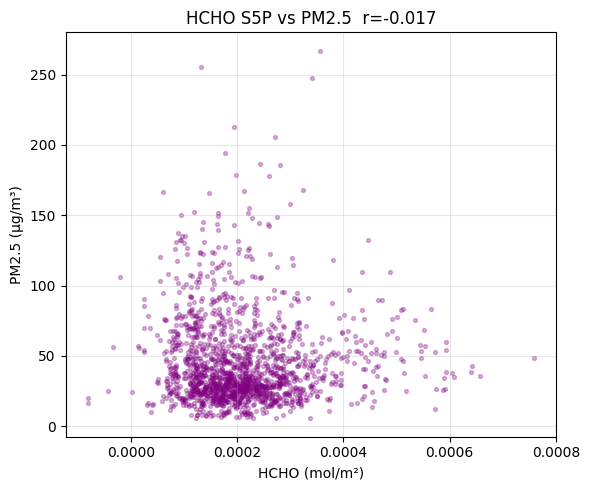

In [7]:
import matplotlib.pyplot as plt

main = pd.read_csv(MERGED, parse_dates=["date"])
hcho_df["date"] = pd.to_datetime(hcho_df["date"])

check = main.merge(hcho_df[["location_id","date","hcho_mean"]],
                   on=["location_id","date"], how="left")
valid = check[["pm25","hcho_mean"]].dropna()
r = valid.corr().iloc[0, 1]
print(f"Pearson r (HCHO S5P vs PM2.5): {r:.3f}  (n={len(valid)})")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(valid["hcho_mean"], valid["pm25"], alpha=0.3, s=8, color="purple")
ax.set_xlabel("HCHO (mol/m²)"); ax.set_ylabel("PM2.5 (μg/m³)")
ax.set_title(f"HCHO S5P vs PM2.5  r={r:.3f}", fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "outputs/hcho_s5p_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

## G. Lưu CSV + Merge vào daily_merged.csv

In [8]:
hcho_cols = ["hcho_valid_pixels", "hcho_mean", "hcho_std",
             "hcho_min", "hcho_max", "hcho_median"]

hcho_df.to_csv(OUT_CSV, index=False)
print(f"Saved: {OUT_CSV}  shape={hcho_df.shape}")

main = pd.read_csv(MERGED, parse_dates=["date"])
for col in hcho_cols:
    if col in main.columns:
        main.drop(columns=[col], inplace=True)

hcho_df["date"] = pd.to_datetime(hcho_df["date"])
merge_cols = ["location_id", "date"] + [c for c in hcho_cols if c in hcho_df.columns]
main = main.merge(hcho_df[merge_cols], on=["location_id","date"], how="left")

for col in hcho_cols:
    if col in main.columns:
        pct = main[col].notna().mean() * 100
        print(f"  {col}: {pct:.1f}% coverage")

main.to_csv(MERGED, index=False)
print(f"\nUpdated: {MERGED}  shape={main.shape}")

Saved: D:\Bussiness_plan\Multimodal_PM25\data\processed\hcho_s5p_daily.csv  shape=(4842, 9)
  hcho_valid_pixels: 100.0% coverage
  hcho_mean: 70.3% coverage
  hcho_std: 70.3% coverage
  hcho_min: 70.3% coverage
  hcho_max: 70.3% coverage
  hcho_median: 70.3% coverage

Updated: D:\Bussiness_plan\Multimodal_PM25\data\processed\daily_merged.csv  shape=(2274, 84)


## H. Thêm vào train_3d_v2.py

```python
# ctx_feats
+ ["hcho_mean", "hcho_median"]

# tab_cols
+ ["hcho_mean", "hcho_max", "hcho_median", "hcho_valid_pixels"]
```

Xóa cache trước khi chạy lại:
```python
import shutil, glob, os
shutil.rmtree('outputs/final_3d_v2/cache', ignore_errors=True)
for f in glob.glob('outputs/final_3d_v2/neural_seed*.pt'): os.remove(f)
```